# Code for comparing the two Wind file options - b and w

In [23]:
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries 
from sunpy.timeseries import GenericTimeSeries
from sunpy.time import parse_time
from sunpy.data import cache
from sunpy.coordinates import spice, frames
from sunpy.coordinates import get_horizons_coord, get_body_heliographic_stonyhurst

from astropy import units as u
from astropy.time import Time

import matplotlib.pyplot as plt
import numpy as np 

import os
import urllib.request

import pandas as pd
import datetime as dt

from scipy.stats import norm
import seaborn as sns

import polars as pl

from kneed import KneeLocator, DataGenerator
from kneed import find_shape
from scipy import stats

import scipy.stats as stats
from scipy.stats import anderson


# uncomment line below to see what datasets are available to query from the CDAWeb
# a.cdaweb.Dataset('OMNI_HRO2_1MIN')#wi_k0_swe # WI_K0_SWE https://cdaweb.gsfc.nasa.gov/misc/NotesW.html#WI_K0_SWE

In [24]:
import warnings
warnings.filterwarnings("ignore")

In [25]:
DataDirectory = "./"
dataName = "wind_min_"
dataNameb = "wind_min_b"
dataNamew = "wind_min_w"


In [95]:
# #Find DateRanges for each file needed found
# def ReadDates(startDate, endDate): #ReadDatesForFileFinding
#     DateRange = pd.date_range(startDate, endDate, freq='MS').strftime("%Y%m%d").tolist()
#     return DateRange

# # Get to date portion of the file names
# def myFunc(e):
#   return e.split("b")[1]

# Get the pre-downloaded data from folder
def FindData(directory, dataName): #FindDataMakeTimeSeries
    files = []
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        if filename.startswith(dataName):
            files.append(directory+filename)
        continue
    # filesSorted = sorted(files, key=myFunc) # sort files
    df_list = [] #pd.DataFrame([])
    # Columns from https://omniweb.gsfc.nasa.gov/html/HROdocum.html
    colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
    for j in range(len(files)):
        df_list.append( pd.read_csv(files[j], header=None, sep = "\s+", names = colnames) )
    dataTimeSeries = pd.concat(df_list, ignore_index=True)

    # replace with nans
    WindFillerVals = [999, 9.9, 999999, 99.99, 9999.99, 99999.9, 999.99, 9999999] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
    dataTimeSeriesFillersToNans = dataTimeSeries.replace(WindFillerVals, np.nan)

    return dataTimeSeriesFillersToNans

def dfToSeries(DataFrame):
    DataFrame.insert(0, "DateTime", pd.to_datetime(DataFrame['Year'] * 10000000 + DataFrame['DOY']*10000 + DataFrame['Hour']*100 + DataFrame['Minute'], format='%Y%j%H%M'))
    DataFrameDateTimeIndex = DataFrame.set_index('DateTime') 

    # colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
    SunpyTimeSeries =  GenericTimeSeries(DataFrameDateTimeIndex)
    # print(SunpyTimeSeries)
    return SunpyTimeSeries

# Calculate Total Vsw
def AddTotVsw(dataTimeSeries):
    TotVsw = np.sqrt(dataTimeSeries.to_dataframe()["Vx_GSE"]**2 + 
                     dataTimeSeries.to_dataframe()["Vy_GSE"]**2 + 
                     dataTimeSeries.to_dataframe()["Vz_GSE"]**2)
    dataTimeSeries = dataTimeSeries.add_column("TotVsw", TotVsw)
    return dataTimeSeries

#Plot Vsw
def PlotVsw(dataTimeSeries, startDate, endDate):
    # dataTimeSeries[cols] = dataTimeSeries[dataTimeSeries[cols] > filter][cols]
    fig, ax = plt.subplots()
    # dataTimeSeries.plot(columns=["TotVsw", "Vx_GSE", "Vy_GSE", "Vz_GSE"], alpha = 0.5)
    dataTimeSeries.plot(columns=["TotVsw"], alpha = 0.5)
    plt.legend(loc="upper right")
    DateRange = pd.date_range(startDate, endDate, freq='D').strftime("%Y%m%d").tolist()
    print(DateRange)
    plt.xlim(DateRange[0], DateRange[1])
    # plt.ylim(-600,600)
    plt.ylim(250,450)
    # print(dataTSFirstDates.to_dataframe()[""].unique())

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddBMag(dataTimeSeries):
    BMag = np.sqrt(dataTimeSeries.to_dataframe()["Bx_GSEGSM"]**2 + 
                   dataTimeSeries.to_dataframe()["ByGSE"]**2 + 
                   dataTimeSeries.to_dataframe()["BzGSE"]**2)
    dataTimeSeries = dataTimeSeries.add_column("BMag", BMag)
    return dataTimeSeries

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddLogBMag(dataTimeSeries):
    LogB = np.log(dataTimeSeries.to_dataframe()["BMag"])
    dataTimeSeries = dataTimeSeries.add_column("LogB", LogB)
    return dataTimeSeries

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddLogBX(dataTimeSeries):
    LogBX = np.log(dataTimeSeries.to_dataframe()["Bx_GSEGSM"])
    dataTimeSeries = dataTimeSeries.add_column("LogBX", LogBX)
    return dataTimeSeries

#Plot B
def PlotB(dataTimeSeries, startDate, endDate):
    fig, ax = plt.subplots()
    dataTimeSeries.plot(columns=["BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"], alpha = 0.5)
    plt.legend(loc="upper right")
    DateRange = pd.date_range(startDate, endDate, freq='D').strftime("%Y%m%d").tolist()
    print(DateRange)
    plt.xlim(DateRange[0], DateRange[1])
    plt.ylim(-20,20)
    # print(dataTSFirstDates.to_dataframe()[""].unique())

# Wind data

## Date ranges

In [96]:
# Start  = "1995-01-01 00:00" # from T&C
Start  = "1998-01-01 00:00" # from SIDC
End  = "1999-12-31 23:59"  # download rest of 2014

def Yearly(startDate, endDate): #ReadDatesForFileFinding
    YearlyRange = pd.date_range(startDate, endDate, freq='YS').strftime("%Y%m%d").tolist()
    return YearlyRange

YearlyRange = Yearly(Start, End)
print(YearlyRange)
# YearlyRange = ['19980101', '19990101']


['19980101', '19990101']


## Find data in files

In [97]:
dataTimeSerieses = []
# StartAndEnd = []
dataname = [dataNameb, dataNamew]
for i in range(2):
    # StartDate = YearlyRange[i][0:4]
    # EndDate = YearlyRange[i+1][0:4]
    # print(StartDate, EndDate)
    # DateRange = ReadDates(StartDate, EndDate) # get date range
    dataFound = FindData(DataDirectory, dataname[i]) # find data
    dataTS = dfToSeries(dataFound)
    dataTS = AddTotVsw(dataTS) # add totvsw
    dataTS = AddBMag(dataTS) # add bmag
    dataTS = AddLogBMag(dataTS) 
    dataTS = AddLogBX(dataTS)
    dataTimeSerieses.append(dataTS)
    # StartAndEnd.append([StartDate, EndDate])

print(dataTimeSerieses[0])
print(dataTimeSerieses[1])

# print(StartAndEnd)

SunPy TimeSeries
----------------
Observatory:			Unknown
Instrument:			Unknown
Channel(s):			Year<br>DOY<br>Hour<br>Minute<br>IMF_PTS<br>PercentInterp<br>CP/MVFlag<br>Timeshift<br>PFN_XGSE<br>PFN_YGSE<br>PFN_ZGSE<br>ScalarB<br>Bx_GSEGSM<br>ByGSE<br>BzGSE<br>ByGSM<br>BzGSM<br>RMSTimeshift<br>RMS_PFN<br>RMSScalarB<br>RMSFieldVector<br>Plasma_PTS<br>FlowSpeed<br>Vx_GSE<br>Vy_GSE<br>Vz_GSE<br>ProtonDensity<br>Temp<br>X_s_c_GSE<br>Y_s_c_GSE<br>Z_s_c_GSE<br>X_targ_GSE<br>Y_targ_GSE<br>Z_targ_GSE<br>RMS_targ<br>DBOT1<br>DBOT2<br>TotVsw<br>BMag<br>LogB<br>LogBX
Start Date:			1998-01-01 00:00:00
End Date:			1998-12-31 23:59:00
Center Date:			1998-07-02 11:59:30
Resolution:			60.0 s
Samples per Channel:		525600
Data Range(s):		Year             0.00E+00<br>DOY              3.64E+02<br>Hour             2.30E+01<br>Minute           5.90E+01<br>IMF_PTS          1.43E+02<br>PercentInterp    1.00E+02<br>CP/MVFlag        1.00E+00<br>Timeshift        1.03E+04<br>PFN_XGSE         9.30E-01<br>PFN_YGSE    

['19980101', '19980102', '19980103', '19980104', '19980105', '19980106', '19980107', '19980108', '19980109', '19980110']
['19980101', '19980102', '19980103', '19980104', '19980105', '19980106', '19980107', '19980108', '19980109', '19980110']


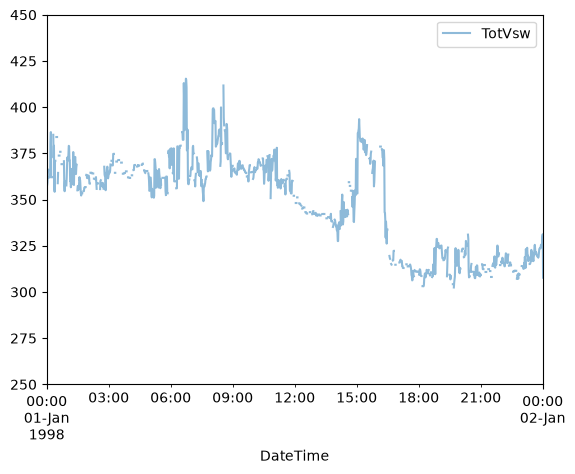

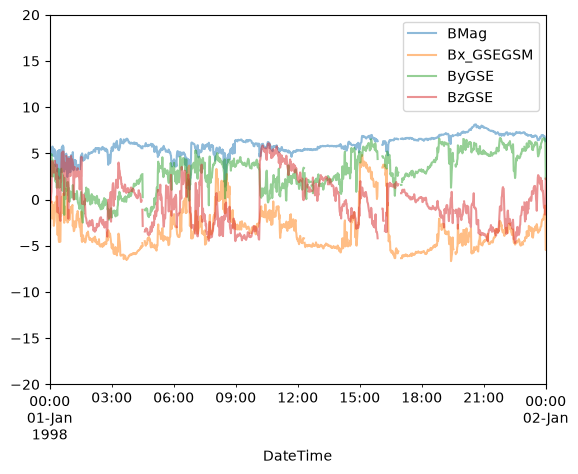

In [98]:
PlotVsw(dataTimeSerieses[0], '19980101', '19980110')
PlotB(dataTimeSerieses[0], '19980101', '19980110')

['19980101', '19980102', '19980103', '19980104', '19980105', '19980106', '19980107', '19980108', '19980109', '19980110']
['19980101', '19980102', '19980103', '19980104', '19980105', '19980106', '19980107', '19980108', '19980109', '19980110']


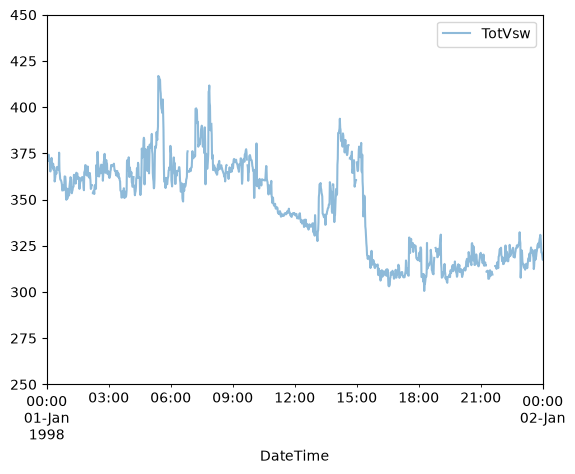

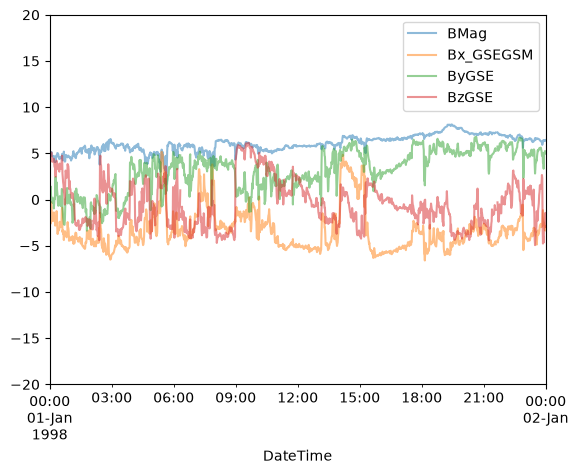

In [99]:
PlotVsw(dataTimeSerieses[1], '19980101', '19980110')
PlotB(dataTimeSerieses[1], '19980101', '19980110')